In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


Clientes

In [2]:
df_clientes = pd.read_csv(r'C:\Shdezg2000\Datasets\Datathone\Datathon_Hey_2026_dataset_transacciones 1\dataset_transacciones\hey_clientes.csv')

In [3]:
df_clientes

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,527,1,app_android,10.0,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,714,3,app_android,8.0,False,True,es_MX,True,2,False
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,454,3,app_ios,8.0,False,True,es_MX,False,2,False
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,...,837,16,app_ios,10.0,True,False,es_MX,True,3,False
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,...,533,1,app_ios,7.0,False,True,es_MX,True,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15020,USR-15021,56,M,Nuevo León,Monterrey,Secundaria,Empleado,40000,1145,True,...,591,16,app_ios,10.0,False,False,es_MX,False,2,False
15021,USR-15022,34,M,Ciudad de México,CDMX - Miguel Hidalgo,Licenciatura,Empleado,13500,1652,False,...,726,4,app_android,6.0,False,False,es_MX,False,2,False
15022,USR-15023,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empleado,19500,671,True,...,473,1,app_ios,7.0,False,False,es_MX,False,1,False
15023,USR-15024,27,M,Ciudad de México,CDMX - Benito Juárez,Licenciatura,Empleado,4500,434,False,...,614,42,app_android,5.0,False,False,es_MX,False,1,False


In [4]:
df_clientes.columns

Index(['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo',
       'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro',
       'nomina_domiciliada', 'canal_apertura', 'score_buro',
       'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10',
       'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro',
       'num_productos_activos', 'patron_uso_atipico'],
      dtype='str')

# Productos

In [5]:
df_prod = pd.read_csv(r'C:\Shdezg2000\Datasets\Datathone\Datathon_Hey_2026_dataset_transacciones 1\dataset_transacciones\hey_productos.csv')

In [6]:
df_prod.shape

(38909, 13)

In [7]:
df_prod.info()

<class 'pandas.DataFrame'>
RangeIndex: 38909 entries, 0 to 38908
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   producto_id              38909 non-null  str    
 1   user_id                  38909 non-null  str    
 2   tipo_producto            38909 non-null  str    
 3   fecha_apertura           38909 non-null  str    
 4   estatus                  38909 non-null  str    
 5   limite_credito           14317 non-null  float64
 6   saldo_actual             35159 non-null  float64
 7   utilizacion_pct          14317 non-null  float64
 8   tasa_interes_anual       18791 non-null  float64
 9   plazo_meses              4550 non-null   float64
 10  monto_mensualidad        4550 non-null   float64
 11  fecha_ultimo_movimiento  38909 non-null  str    
 12  es_dato_sintetico        38909 non-null  bool   
dtypes: bool(1), float64(6), str(6)
memory usage: 5.9 MB


In [8]:
df_prod.isna().sum()

producto_id                    0
user_id                        0
tipo_producto                  0
fecha_apertura                 0
estatus                        0
limite_credito             24592
saldo_actual                3750
utilizacion_pct            24592
tasa_interes_anual         20118
plazo_meses                34359
monto_mensualidad          34359
fecha_ultimo_movimiento        0
es_dato_sintetico              0
dtype: int64

In [9]:
lista=['tarjeta_credito_hey','tarjeta_credito_garantizada','tarjeta_credito_negocios','credito_personal','credito_auto','credito_nomina']
df_prod.loc[df_prod['tipo_producto'].isin(lista)].shape[0]

14317

In [10]:
lista=['seguro_vida','seguro_compras','cuenta_negocios','inversion_hey','cuenta_debito']
df_prod.loc[df_prod['tipo_producto'].isin(lista)& df_prod['limite_credito'].isna()].shape[0]

24592

Transacciones

In [11]:
df_trans = pd.read_csv(r'C:\Shdezg2000\Datasets\Datathone\Datathon_Hey_2026_dataset_transacciones 1\dataset_transacciones\hey_transacciones.csv')

In [12]:
df_trans

,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,1,NaN,0.34,Cargo automático,14,Wednesday,True,app_ios,False,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,1,NaN,NaN,Cargo automático,0,Friday,False,app_ios,False,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,1,NaN,NaN,inv hey,22,Friday,False,app_huawei,False,True
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,1,NaN,NaN,SPEI enviado,11,Sunday,False,app_android,False,True
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,1,NaN,5.69,dep. efvo,7,Saturday,False,app_ios,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802379,TXN-0000802181,USR-15025,PRD-00038909,2025-10-31 01:07:07,compra,app_android,14659.40,AutoRenta MX,transporte,CDMX - Miguel Hidalgo,...,1,NaN,NaN,cobro membresia,1,Friday,False,app_android,True,True
802380,TXN-0000802209,USR-15025,PRD-00038907,2025-11-02 03:22:38,cargo_recurrente,app_ios,649.00,GamerPass,servicios_digitales,CDMX - Miguel Hidalgo,...,1,NaN,NaN,crg recur,3,Sunday,False,app_ios,True,True
802381,TXN-0000802182,USR-15025,PRD-00038909,2025-11-06 15:26:52,compra,app_android,3124.38,AeroLink MX,viajes,CDMX - Miguel Hidalgo,...,1,NaN,NaN,compra en lnea,15,Thursday,False,app_android,True,True
802382,TXN-0000802170,USR-15025,PRD-00038907,2025-11-13 05:45:30,deposito_oxxo,oxxo,500.00,NaN,transferencia,CDMX - Miguel Hidalgo,...,1,NaN,NaN,COMPRA TRNDA,5,Thursday,False,NaN,True,True


Conversaciones

In [13]:
df_conver = pd.read_csv(r'C:\Shdezg2000\Datasets\Datathone\Datathon_Hey_dataset_conversaciones 1\dataset_conversaciones\dataset_50k_anonymized.csv')

In [14]:
df_conver.columns

Index(['input', 'output', 'date', 'conv_id', 'user_id', 'channel_source'], dtype='str')

In [15]:
df_conver['channel_source'].unique()
df_conver['channel_source'].value_counts()

channel_source
1    46936
2     3063
Name: count, dtype: int64

In [16]:
df_conver

,input,output,date,conv_id,user_id,channel_source
0,"Me enteré de una promo ""Supercashback Pagos Gu...",Claro que puedo ayudarte! Para participar en l...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
1,La tarjeta de crédito Hey Negocios es diferent...,Claro! La Tarjeta de Crédito Hey Negocios es d...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
2,"Entiendo, gracias",¡De nada! Me alegra haber podido ayudarte. Si ...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
3,Hola,¡Hola! ¿Cómo estás? Estoy aquí para ayudarte c...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1
4,Verificación de cuenta,Claro que puedo ayudarte con eso. Para validar...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1
...,...,...,...,...,...,...
49994,Cómo puedo verificar tarjeta para usar en Appl...,Claro que puedo ayudarte con eso. Para verific...,2025-10-25,221B2A02-FA14-451B-916A-5DE70CCC3679,USR-04904,1
49995,Hola no puedo hacer un retiro sin Tarjeta y,Lamento escuchar eso. Para hacer un retiro sin...,2025-09-30,5769ccdd-6bd3-48bf-9953-6fd4c4e5f1a1,USR-11158,1
49996,Hice una queja y me pide una contraseña provic...,Claro que puedo ayudarte. Para seguir el progr...,2025-08-23,f742315f-5064-4467-a3da-d3476e2f3c28,USR-13210,1
49997,No me deja transferir porque me dice que el to...,Lamento escuchar eso. Si estás teniendo proble...,2025-10-18,8543484E-49DA-4341-B1F6-08FEC214E6A3,USR-02245,1


In [17]:
df_prod

,producto_id,user_id,tipo_producto,fecha_apertura,estatus,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico
0,PRD-00000001,USR-00001,cuenta_debito,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
1,PRD-00000002,USR-00001,tarjeta_credito_hey,2022-10-16,activo,144000.0,88790.40,0.6166,35.71,NaN,NaN,2025-09-17,True
2,PRD-00000003,USR-00002,cuenta_debito,2025-04-03,activo,NaN,20712.54,NaN,NaN,NaN,NaN,2025-10-16,True
3,PRD-00000004,USR-00002,tarjeta_credito_hey,2025-07-18,activo,22000.0,6122.60,0.2783,34.08,NaN,NaN,2025-09-15,True
4,PRD-00000005,USR-00003,cuenta_debito,2023-03-26,activo,NaN,3454.65,NaN,NaN,NaN,NaN,2025-09-27,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38904,PRD-00038905,USR-15024,cuenta_debito,2025-04-12,cancelado,NaN,34705.75,NaN,NaN,NaN,NaN,2025-09-02,True
38905,PRD-00038906,USR-15024,tarjeta_credito_garantizada,2025-10-08,activo,10000.0,2032.00,0.2032,44.93,NaN,NaN,2025-11-10,True
38906,PRD-00038907,USR-15025,cuenta_debito,2025-09-10,activo,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,True
38907,PRD-00038908,USR-15025,cuenta_negocios,2025-07-16,activo,NaN,21770.60,NaN,NaN,NaN,NaN,2025-09-06,True


In [18]:
df_prod.columns

Index(['producto_id', 'user_id', 'tipo_producto', 'fecha_apertura', 'estatus',
       'limite_credito', 'saldo_actual', 'utilizacion_pct',
       'tasa_interes_anual', 'plazo_meses', 'monto_mensualidad',
       'fecha_ultimo_movimiento', 'es_dato_sintetico'],
      dtype='str')

In [19]:
# Tipos de producto y estatus a evaluar
tipos_objetivo = ['seguro_vida', 'seguro_compras', 'cuenta_negocios']
estatus_validos = ['activo', 'cancelado', 'suspendido']

# Filtrar df_productos solo con los estatus relevantes
df_filtrado = df_prod[df_prod['estatus'].isin(estatus_validos)]

# Crear las 3 nuevas columnas en el dataset de clientes
for tipo in tipos_objetivo:
    # Obtener user_ids que tienen ese tipo de producto
    ids_con_producto = df_filtrado[df_filtrado['tipo_producto'] == tipo]['user_id'].unique()
    
    # Agregar columna al dataset de clientes
    df_clientes[tipo] = df_clientes['user_id'].isin(ids_con_producto)

In [20]:
# Estandariza ambos IDs a string y quita espacios

try:
    pou=pd.merge(df_trans,df_clientes,on='user_id',how='left',validate='many_to_one')
    print(f'si funciona {len(pou)}')
except Exception as e:
    print(f'Error: {e}')
    
pou
    

si funciona 802384


,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico_y,seguro_vida,seguro_compras,cuenta_negocios
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,10.0,False,True,es_MX,False,2,False,False,False,False
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,10.0,False,True,es_MX,False,2,False,False,False,False
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,10.0,False,True,es_MX,False,2,False,False,False,False
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,10.0,False,True,es_MX,False,2,False,False,False,False
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,10.0,False,True,es_MX,False,2,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802379,TXN-0000802181,USR-15025,PRD-00038909,2025-10-31 01:07:07,compra,app_android,14659.40,AutoRenta MX,transporte,CDMX - Miguel Hidalgo,...,8.0,False,True,es_MX,False,3,True,False,False,True
802380,TXN-0000802209,USR-15025,PRD-00038907,2025-11-02 03:22:38,cargo_recurrente,app_ios,649.00,GamerPass,servicios_digitales,CDMX - Miguel Hidalgo,...,8.0,False,True,es_MX,False,3,True,False,False,True
802381,TXN-0000802182,USR-15025,PRD-00038909,2025-11-06 15:26:52,compra,app_android,3124.38,AeroLink MX,viajes,CDMX - Miguel Hidalgo,...,8.0,False,True,es_MX,False,3,True,False,False,True
802382,TXN-0000802170,USR-15025,PRD-00038907,2025-11-13 05:45:30,deposito_oxxo,oxxo,500.00,NaN,transferencia,CDMX - Miguel Hidalgo,...,8.0,False,True,es_MX,False,3,True,False,False,True


In [21]:
pou_exe=pd.merge(pou,df_prod,on='producto_id',how='left',validate='many_to_one')
pou_exe

,transaccion_id,user_id_x,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,fecha_apertura,estatus_y,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico_y
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,2022-10-16,activo,144000.0,88790.40,0.6166,35.71,NaN,NaN,2025-09-17,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802379,TXN-0000802181,USR-15025,PRD-00038909,2025-10-31 01:07:07,compra,app_android,14659.40,AutoRenta MX,transporte,CDMX - Miguel Hidalgo,...,2025-07-09,activo,169000.0,89772.80,0.5312,54.68,NaN,NaN,2025-09-23,True
802380,TXN-0000802209,USR-15025,PRD-00038907,2025-11-02 03:22:38,cargo_recurrente,app_ios,649.00,GamerPass,servicios_digitales,CDMX - Miguel Hidalgo,...,2025-09-10,activo,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,True
802381,TXN-0000802182,USR-15025,PRD-00038909,2025-11-06 15:26:52,compra,app_android,3124.38,AeroLink MX,viajes,CDMX - Miguel Hidalgo,...,2025-07-09,activo,169000.0,89772.80,0.5312,54.68,NaN,NaN,2025-09-23,True
802382,TXN-0000802170,USR-15025,PRD-00038907,2025-11-13 05:45:30,deposito_oxxo,oxxo,500.00,NaN,transferencia,CDMX - Miguel Hidalgo,...,2025-09-10,activo,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,True


In [22]:
pou_exe.columns

Index(['transaccion_id', 'user_id_x', 'producto_id', 'fecha_hora',
       'tipo_operacion', 'canal', 'monto', 'comercio_nombre', 'categoria_mcc',
       'ciudad_transaccion', 'estatus_x', 'motivo_no_procesada',
       'intento_numero', 'meses_diferidos', 'cashback_generado',
       'descripcion_libre', 'hora_del_dia', 'dia_semana', 'es_internacional',
       'dispositivo', 'patron_uso_atipico_x', 'es_dato_sintetico_x', 'edad',
       'sexo', 'estado', 'ciudad', 'nivel_educativo', 'ocupacion',
       'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro',
       'nomina_domiciliada', 'canal_apertura', 'score_buro',
       'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10',
       'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro',
       'num_productos_activos', 'patron_uso_atipico_y', 'seguro_vida',
       'seguro_compras', 'cuenta_negocios', 'user_id_y', 'tipo_producto',
       'fecha_apertura', 'estatus_y', 'limite_credito', 'saldo_actual',
       '

In [23]:
pou_exe['fecha_hora'] = pd.to_datetime(pou_exe['fecha_hora']).dt.date
pou_exe[['fecha_hora','hora_del_dia','dia_semana']]

,fecha_hora,hora_del_dia,dia_semana
0,2025-01-15,14,Wednesday
1,2025-01-17,0,Friday
2,2025-01-17,22,Friday
3,2025-01-19,11,Sunday
4,2025-02-15,7,Saturday
...,...,...,...
802379,2025-10-31,1,Friday
802380,2025-11-02,3,Sunday
802381,2025-11-06,15,Thursday
802382,2025-11-13,5,Thursday


In [24]:
(pou_exe['user_id_x'] == pou_exe['user_id_y']).all()

np.True_

In [25]:
pou_exe = pou_exe.drop(columns=['user_id_y', 'estatus_y', 'patron_uso_atipico_y', 'es_dato_sintetico_y'])

In [26]:
pou_exe.shape

(802384, 54)

In [27]:
pou_exe = pou_exe.rename(columns={
    'user_id_x':              'user_id',
    'estatus_x':              'estatus',
    'patron_uso_atipico_x':   'patron_uso_atipico',
    'es_dato_sintetico_x':    'es_dato_sintetico'
})

In [28]:
for col in pou_exe.columns:
    if pou_exe[col].dtype == 'bool':
        pou_exe[col] = pou_exe[col].astype(int)
        

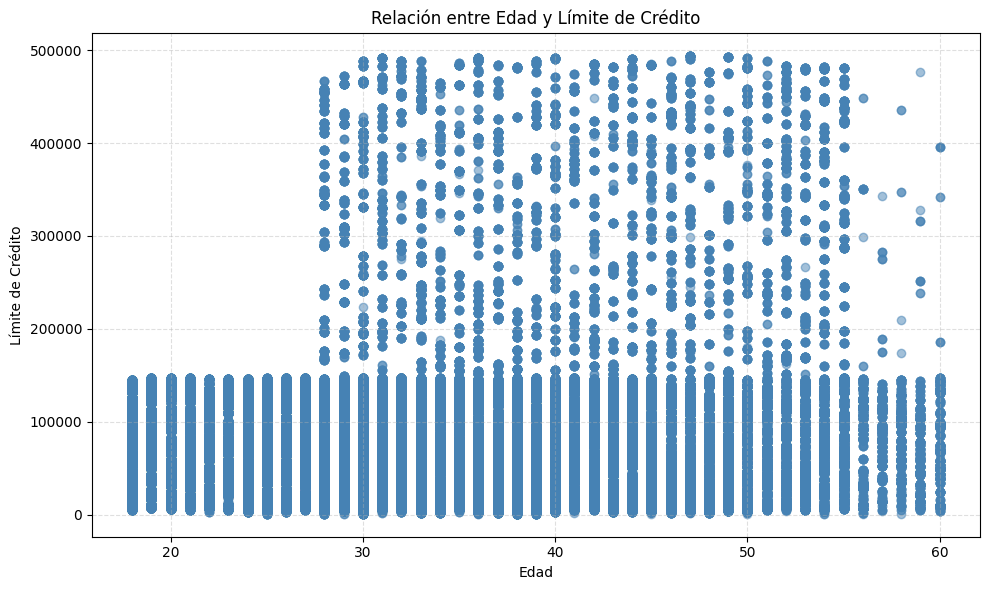

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(pou_exe['edad'], pou_exe['limite_credito'], alpha=0.5, color='steelblue')

plt.title('Relación entre Edad y Límite de Crédito')
plt.xlabel('Edad')
plt.ylabel('Límite de Crédito')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

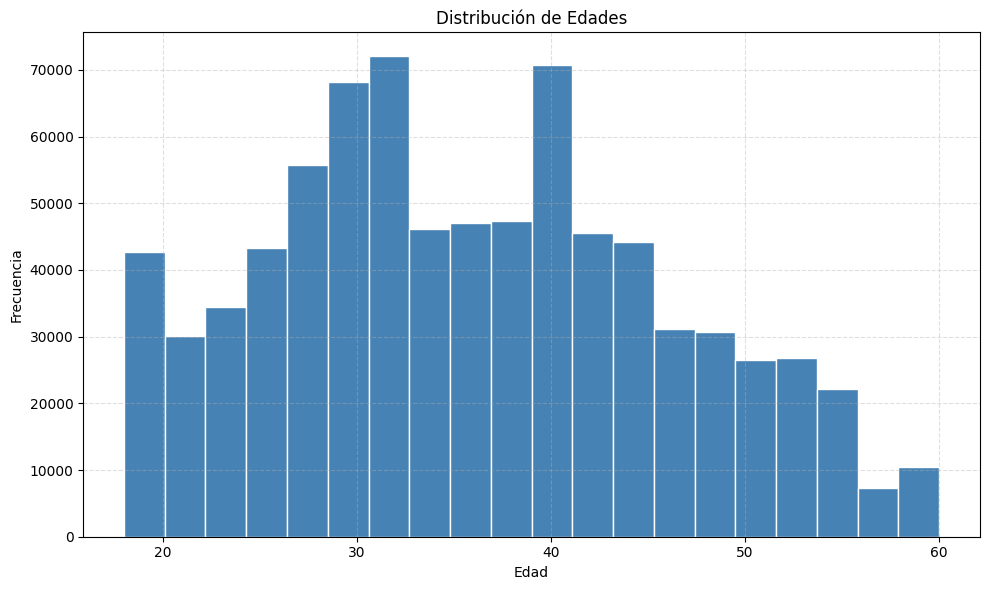

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(pou_exe['edad'], bins=20, color='steelblue', edgecolor='white')

plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [31]:
# Definir los grupos de edad
bins = [0, 30, 45, pou_exe['edad'].max()]
labels = ['Jóvenes (18-30)', 'Adultos (31-45)', 'Tercera Edad (46+)']

pou_exe['grupo_edad'] = pd.cut(pou_exe['edad'], bins=bins, labels=labels)

# Contar y calcular porcentaje
conteo = pou_exe['grupo_edad'].value_counts().sort_index()
porcentaje = (conteo / conteo.sum() * 100).round(2)

resumen_edad = pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje': porcentaje
})

print(resumen_edad)

                    Cantidad  Porcentaje
grupo_edad                              
Jóvenes (18-30)       274511       34.21
Adultos (31-45)       372902       46.47
Tercera Edad (46+)    154971       19.31


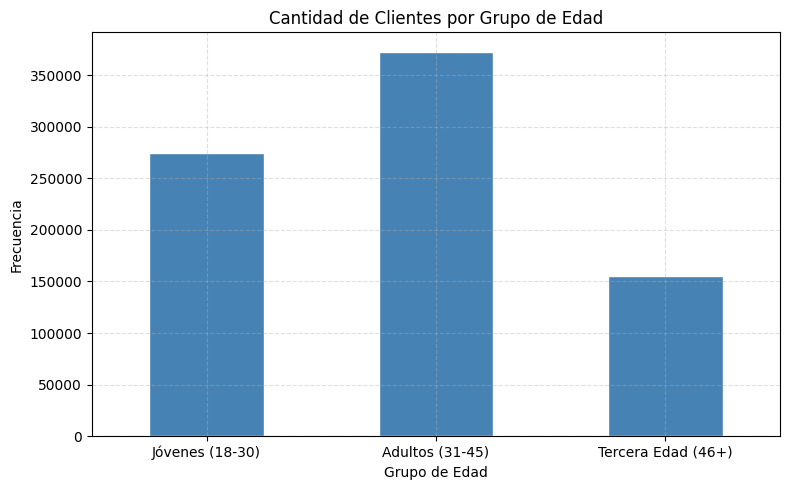

In [32]:
conteo.plot(kind='bar', color='steelblue', edgecolor='white', figsize=(8, 5))
plt.title('Cantidad de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [33]:
# Ver desbalance en todas las variables categóricas
columnas_categoricas = pou_exe.select_dtypes(include=['object', 'category']).columns

resumen_desbalance = {}

for col in columnas_categoricas:
    frecuencias = pou_exe[col].value_counts(normalize=True) * 100
    clase_dominante = frecuencias.iloc[0]
    resumen_desbalance[col] = {
        'clase_dominante': frecuencias.index[0],
        'porcentaje_dominante': round(clase_dominante, 2),
        'num_clases': pou_exe[col].nunique(),
        'desbalanceada': clase_dominante > 80
    }

resumen_desbalance_df = pd.DataFrame(resumen_desbalance).T
print(resumen_desbalance_df.sort_values('porcentaje_dominante', ascending=False))

C:\Users\shdez\AppData\Local\Temp\ipykernel_12188\1014658559.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = pou_exe.select_dtypes(include=['object', 'category']).columns


                                    clase_dominante porcentaje_dominante  \
idioma_preferido                              es_MX                96.71   
estatus                                  completada                93.26   
canal_apertura                                  App                81.26   
tipo_producto                         cuenta_debito                76.52   
ocupacion                                  Empleado                56.56   
sexo                                              M                48.32   
grupo_edad                          Adultos (31-45)                46.47   
preferencia_canal                           app_ios                46.09   
categoria_mcc                         transferencia                45.74   
dispositivo                                 app_ios                44.69   
nivel_educativo                        Licenciatura                43.26   
tipo_operacion                               compra                39.82   
canal       

count    802384.000000
mean       6108.495959
std        9885.308664
min           5.010000
25%         540.000000
50%        1740.000000
75%        7030.937500
max       79511.300000
Name: monto, dtype: float64
Varianza: 97719327.39
Coef. variación: 161.83%


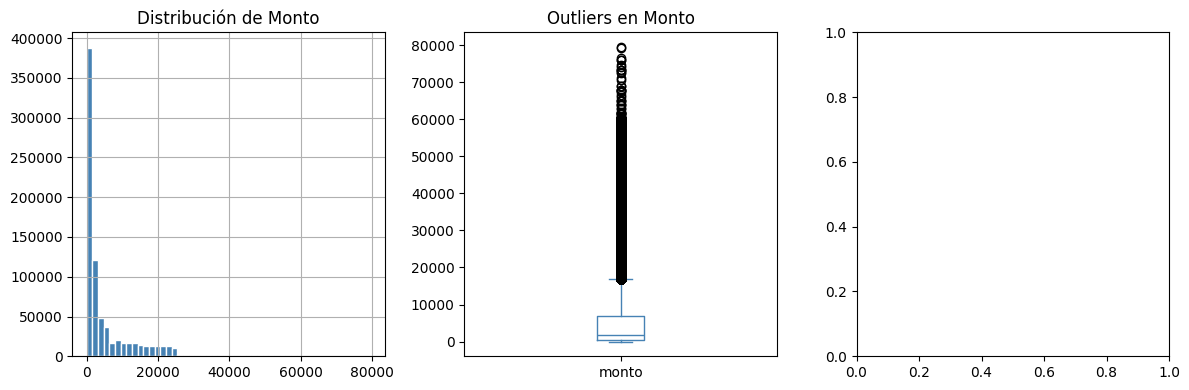

In [34]:
import seaborn as sns

# 1. Estadísticas descriptivas
print(pou_exe['monto'].describe())

# 2. Distribución
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
pou_exe['monto'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución de Monto')

# 3. Boxplot para detectar outliers
plt.subplot(1, 3, 2)
pou_exe['monto'].plot(kind='box', color='steelblue')
plt.title('Outliers en Monto')

# 4. Varianza — si es casi cero no aporta al clustering
plt.subplot(1, 3, 3)
print(f'Varianza: {pou_exe["monto"].var():.2f}')
print(f'Coef. variación: {(pou_exe["monto"].std() / pou_exe["monto"].mean() * 100):.2f}%')

plt.tight_layout()
plt.show()

In [35]:
# Ver cantidad de valores únicos
print(f'Valores únicos: {pou_exe["comercio_nombre"].nunique()}')

# Ver las más frecuentes
print(pou_exe['comercio_nombre'].value_counts().head(10))

# Ver qué porcentaje representa el top 10
top10_pct = (pou_exe['comercio_nombre'].value_counts().head(10).sum() / len(pou_exe) * 100).round(2)
print(f'Top 10 comercios representan: {top10_pct}%')

Valores únicos: 75
comercio_nombre
PodcastHub          15483
CloudDrive MX       15481
GamerPass           15418
NewsDigital MX      15409
MusicFlow MX        15401
StreamPlus          15365
Gobierno MX Pago    12389
CFE Digital         12339
Predial MX          12295
IMPI Servicios      12272
Name: count, dtype: int64
Top 10 comercios representan: 17.68%


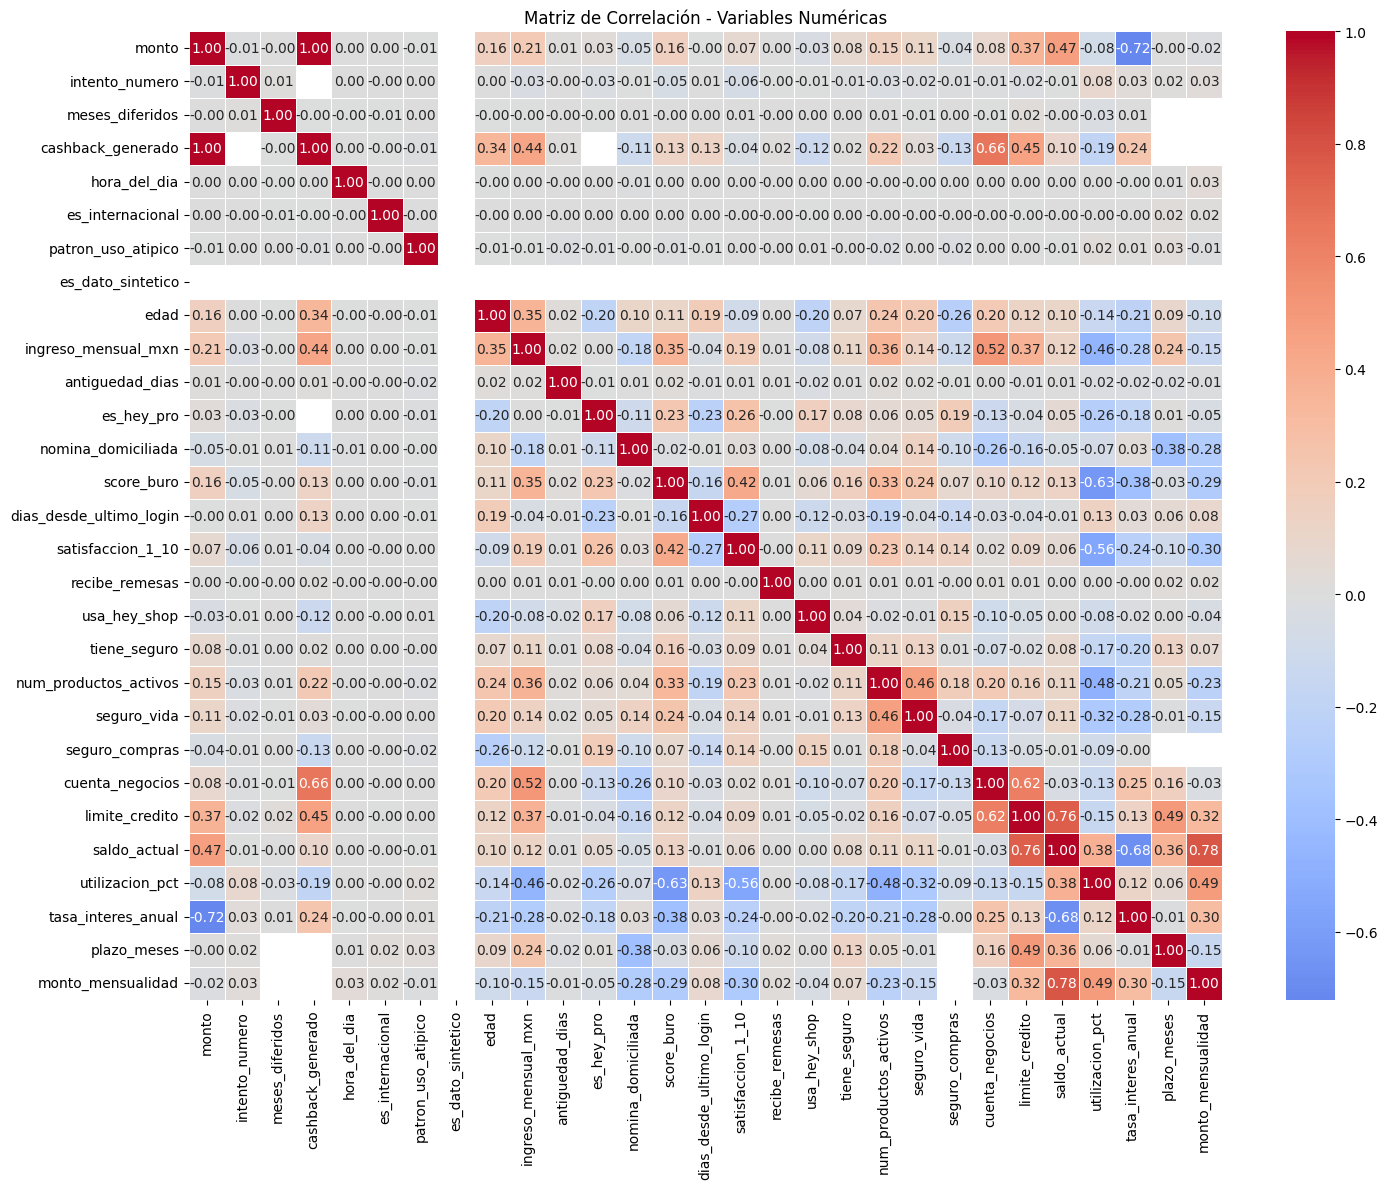

In [36]:
import seaborn as sns

# Seleccionar solo variables numéricas
numericas = pou_exe.select_dtypes(include=['int64', 'float64']).columns

# Matriz de correlación
plt.figure(figsize=(15, 12))
sns.heatmap(
    pou_exe[numericas].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

In [37]:
# Identificar pares con correlación > 0.70
correlacion = pou_exe[numericas].corr()

pares_alta_correlacion = []

for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        if abs(correlacion.iloc[i, j]) > 0.70:
            pares_alta_correlacion.append({
                'variable_1': correlacion.columns[i],
                'variable_2': correlacion.columns[j],
                'correlacion': round(correlacion.iloc[i, j], 2)
            })

pares_df = pd.DataFrame(pares_alta_correlacion).sort_values('correlacion', ascending=False)
print(pares_df)

       variable_1          variable_2  correlacion
0           monto   cashback_generado         1.00
3    saldo_actual   monto_mensualidad         0.78
2  limite_credito        saldo_actual         0.76
1           monto  tasa_interes_anual        -0.72


In [38]:
pou_exe

,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,tipo_producto,fecha_apertura,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,grupo_edad
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,tarjeta_credito_hey,2022-10-16,144000.0,88790.40,0.6166,35.71,NaN,NaN,2025-09-17,Jóvenes (18-30)
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,cuenta_debito,2023-06-26,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,Jóvenes (18-30)
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,cuenta_debito,2023-06-26,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,Jóvenes (18-30)
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,cuenta_debito,2023-06-26,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,Jóvenes (18-30)
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,cuenta_debito,2023-06-26,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,Jóvenes (18-30)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802379,TXN-0000802181,USR-15025,PRD-00038909,2025-10-31,compra,app_android,14659.40,AutoRenta MX,transporte,CDMX - Miguel Hidalgo,...,tarjeta_credito_negocios,2025-07-09,169000.0,89772.80,0.5312,54.68,NaN,NaN,2025-09-23,Tercera Edad (46+)
802380,TXN-0000802209,USR-15025,PRD-00038907,2025-11-02,cargo_recurrente,app_ios,649.00,GamerPass,servicios_digitales,CDMX - Miguel Hidalgo,...,cuenta_debito,2025-09-10,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,Tercera Edad (46+)
802381,TXN-0000802182,USR-15025,PRD-00038909,2025-11-06,compra,app_android,3124.38,AeroLink MX,viajes,CDMX - Miguel Hidalgo,...,tarjeta_credito_negocios,2025-07-09,169000.0,89772.80,0.5312,54.68,NaN,NaN,2025-09-23,Tercera Edad (46+)
802382,TXN-0000802170,USR-15025,PRD-00038907,2025-11-13,deposito_oxxo,oxxo,500.00,NaN,transferencia,CDMX - Miguel Hidalgo,...,cuenta_debito,2025-09-10,NaN,73783.98,NaN,NaN,NaN,NaN,2025-11-26,Tercera Edad (46+)


In [39]:
print(f'Valores únicos: {pou_exe["ciudad_transaccion"].nunique()}')

Valores únicos: 93


In [40]:
print(f'Valores únicos: {pou_exe["estado"].nunique()}')

Valores únicos: 17


In [41]:
print(f'Valores únicos: {pou_exe["descripcion_libre"].nunique()}')
print(pou_exe['descripcion_libre'].head(5))

Valores únicos: 36
0    Cargo automático
1    Cargo automático
2             inv hey
3        SPEI enviado
4           dep. efvo
Name: descripcion_libre, dtype: str


In [42]:
# Ver distribución completa
print(pou_exe['descripcion_libre'].value_counts(normalize=True) * 100)

descripcion_libre
ret. cajero         2.813678
SPEI env            2.812733
CARGO RECUR         2.812328
PAG SERV            2.805847
Compra en línea     2.804092
compra tienda       2.803552
Inversion Hey       2.802471
RET CAJERO          2.800176
transf spei         2.797476
compra en lnea      2.796260
inv hey             2.789239
DEP EFECTIVO        2.788969
cobro membresia     2.785324
pago efectuado      2.783839
abono inv           2.783704
Pago Efectuado      2.783434
trnsf SPEI          2.783029
dep. efvo           2.771957
pgo efctuado        2.771822
dep OXXO            2.771687
ret cajero auto     2.771417
Cargo automático    2.770472
SPEI enviado        2.769932
cargo automatico    2.769797
Suscripción dig     2.767366
pago srvc           2.766421
INV HEY             2.765611
crg recur           2.764666
Pago srv            2.761965
srv pago            2.756835
PAGO EFECTUADO      2.754674
SUSCRIP             2.754269
COMPRA TRNDA        2.748193
membresía dig.      2.743

IMputacion de variables

In [43]:
# Imputar satisfaccion_1_10 antes de cualquier transformación
def imputar_por_grupo(df, columna, grupos):
    df = df.copy()
    moda_por_grupo = df.groupby(grupos)[columna].apply(
        lambda x: x.mode()[0] if not x.mode().empty else None
    )
    for grupo, moda in moda_por_grupo.items():
        mask = (
            (df[grupos[0]] == grupo[0]) & 
            (df[grupos[1]] == grupo[1]) & 
            (df[columna].isnull())
        )
        df.loc[mask, columna] = moda
    
    # Si quedan nulos imputar con moda global
    df[columna] = df[columna].fillna(df[columna].mode()[0])
    return df

pou_exe = imputar_por_grupo(
    pou_exe, 
    'satisfaccion_1_10', 
    ['estatus', 'tipo_producto']
)

# Verificar
print(f'Nulos en satisfaccion_1_10: {pou_exe["satisfaccion_1_10"].isnull().sum()}')

Nulos en satisfaccion_1_10: 0


Dropeo de variables

In [44]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# # Ver cuántas componentes explican el 95% de varianza
# pca = PCA()
# pca.fit(X_train)

# varianza_acumulada = pca.explained_variance_ratio_.cumsum()

# plt.figure(figsize=(10, 5))
# plt.plot(varianza_acumulada, color='steelblue')
# plt.axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
# plt.xlabel('Número de componentes')
# plt.ylabel('Varianza acumulada')
# plt.title('PCA - Varianza Explicada')
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()

# # Cuántas componentes necesitas
# n_componentes = (varianza_acumulada >= 0.95).argmax() + 1
# print(f'Componentes para 95% varianza: {n_componentes}')

In [45]:
# X = pd.DataFrame(X_train_pca)
# X.describe().T

In [46]:
aaa=pou_exe.copy()

In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# ─── PASO 1: Guardar user_id aparte ──────────────────────
user_ids = pou_exe['user_id'].copy()

# ─── PASO 2: Transformaciones antes del dropeo ────────────
# Log transform para monto
pou_exe['monto_log'] = np.log1p(pou_exe['monto'])

# Dias sin movimiento desde fecha
pou_exe['dias_sin_movimiento'] = (
    pd.Timestamp.now() - pd.to_datetime(pou_exe['fecha_ultimo_movimiento'])
).dt.days

# ─── PASO 3: DROPEO COMPLETO ──────────────────────────────
pou_exe = pou_exe.drop(columns=[
    # IDs
    'user_id',
    'transaccion_id',
    'producto_id',
    # Fechas crudas
    'fecha_hora',
    'fecha_apertura',
    'fecha_ultimo_movimiento',
    # Alta cardinalidad
    'comercio_nombre',
    'ciudad_transaccion',
    'ciudad',
    # Correlación alta
    'cashback_generado',
    'tasa_interes_anual',
    'saldo_actual',
    'monto_mensualidad',
    'monto',
    # Demográficas y discriminatorias
    'edad',
    'grupo_edad',
    'sexo',
    'estado',
    'nivel_educativo',
    'ocupacion',
    'idioma_preferido',
    # Nulos críticos +80%
    'plazo_meses',
    'meses_diferidos',
    'limite_credito',
    'utilizacion_pct'
])

print(f'Variables después de dropeo: {pou_exe.shape[1]}')

# ─── PASO 4: Encoding booleanas ───────────────────────────
columnas_bool = pou_exe.select_dtypes(include='bool').columns
pou_exe[columnas_bool] = pou_exe[columnas_bool].astype(int)

# ─── PASO 5: Encoding categóricas ─────────────────────────
columnas_cat = pou_exe.select_dtypes(include='object').columns
pou_exe = pd.get_dummies(pou_exe, columns=columnas_cat, drop_first=True)

print(f'Variables después de encoding: {pou_exe.shape[1]}')

# ─── PASO 6: Split estratificado ──────────────────────────
pou_exe['estratificacion'] = (
    pou_exe['estatus_en_disputa'].astype(str) + '_' +
    pou_exe['canal_apertura_Fan Shop'].astype(str)
)

X_train, X_val = train_test_split(
    pou_exe,
    test_size=0.2,
    random_state=42,
    stratify=pou_exe['estratificacion']
)

X_train = X_train.drop(columns=['estratificacion'])
X_val   = X_val.drop(columns=['estratificacion'])

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')

# ─── PASO 7: Normalización y Estandarización ──────────────
# Variables con outliers → StandardScaler
cols_standard = ['ingreso_mensual_mxn', 'score_buro', 'monto_log']

# Resto de numéricas → MinMaxScaler
cols_minmax = X_train.select_dtypes(
    include=['float64', 'int64']
).columns.difference(cols_standard)

# Fit SOLO en train
scaler_standard = StandardScaler()
scaler_minmax   = MinMaxScaler()

X_train[cols_standard] = scaler_standard.fit_transform(X_train[cols_standard])
X_val[cols_standard]   = scaler_standard.transform(X_val[cols_standard])

X_train[cols_minmax]   = scaler_minmax.fit_transform(X_train[cols_minmax])
X_val[cols_minmax]     = scaler_minmax.transform(X_val[cols_minmax])

# ─── PASO 8: PCA ──────────────────────────────────────────
pca = PCA(n_components=70)

X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)

print(f'Train después de PCA: {X_train_pca.shape}')
print(f'Val después de PCA:   {X_val_pca.shape}')

Variables después de dropeo: 32


C:\Users\shdez\AppData\Local\Temp\ipykernel_12188\3587451326.py:61: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_cat = pou_exe.select_dtypes(include='object').columns


Variables después de encoding: 116
Train: (641907, 116)
Val:   (160477, 116)
Train después de PCA: (641907, 70)
Val después de PCA:   (160477, 70)


VRNN

In [48]:
columns_to_drop = [
    'transaccion_id',
    'producto_id',
    'comercio_nombre',
    'ciudad_transaccion',
    'motivo_no_procesada',
    'intento_numero',
    'descripcion_libre',
    'dispositivo',
    'es_dato_sintetico',
    'estado',
    'ciudad',
    'canal_apertura',
    'idioma_preferido',
    'fecha_apertura',
    'tasa_interes_anual',
    'plazo_meses',
    'monto_mensualidad',
    'preferencia_canal'
]

df_vrnn = aaa.drop(columns=columns_to_drop)

print(f"Columnas restantes ({len(df_vrnn.columns)}):")
print(df_vrnn.columns.tolist())

Columnas restantes (37):
['user_id', 'fecha_hora', 'tipo_operacion', 'canal', 'monto', 'categoria_mcc', 'estatus', 'meses_diferidos', 'cashback_generado', 'hora_del_dia', 'dia_semana', 'es_internacional', 'patron_uso_atipico', 'edad', 'sexo', 'nivel_educativo', 'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro', 'nomina_domiciliada', 'score_buro', 'dias_desde_ultimo_login', 'satisfaccion_1_10', 'recibe_remesas', 'usa_hey_shop', 'tiene_seguro', 'num_productos_activos', 'seguro_vida', 'seguro_compras', 'cuenta_negocios', 'tipo_producto', 'limite_credito', 'saldo_actual', 'utilizacion_pct', 'fecha_ultimo_movimiento', 'grupo_edad']


In [49]:
import pandas as pd
import numpy as np

# Tipos correctos
df_vrnn['fecha_hora'] = pd.to_datetime(df_vrnn['fecha_hora'])
df_vrnn['fecha_ultimo_movimiento'] = pd.to_datetime(df_vrnn['fecha_ultimo_movimiento'])

# Ordenar por usuario y tiempo (base para la secuencia)
df_vrnn = df_vrnn.sort_values(['user_id', 'fecha_hora']).reset_index(drop=True)

# --- Nulos con significado propio ---
df_vrnn['meses_diferidos'] = df_vrnn['meses_diferidos'].fillna(0)
df_vrnn['cashback_generado'] = df_vrnn['cashback_generado'].fillna(0)
df_vrnn['limite_credito'] = df_vrnn['limite_credito'].fillna(0)
df_vrnn['saldo_actual'] = df_vrnn['saldo_actual'].fillna(0)
df_vrnn['utilizacion_pct'] = df_vrnn['utilizacion_pct'].fillna(0)

# --- Nulos que SÍ son señal: crear flag antes de imputar ---
df_vrnn['sin_login_reciente'] = df_vrnn['dias_desde_ultimo_login'].isnull().astype(int)
df_vrnn['dias_desde_ultimo_login'] = df_vrnn['dias_desde_ultimo_login'].fillna(999)

df_vrnn['sin_historial_buro'] = df_vrnn['score_buro'].isnull().astype(int)
df_vrnn['score_buro'] = df_vrnn['score_buro'].fillna(0)

df_vrnn['nunca_respondio_encuesta'] = df_vrnn['satisfaccion_1_10'].isnull().astype(int)
df_vrnn['satisfaccion_1_10'] = df_vrnn['satisfaccion_1_10'].fillna(-1)

df_vrnn['monto_nulo'] = df_vrnn['monto'].isnull().astype(int)
df_vrnn['monto'] = df_vrnn['monto'].fillna(0)

# Eliminar duplicados exactos
df_vrnn = df_vrnn.drop_duplicates()

# Verificar nulos restantes
nulos_restantes = df_vrnn.isnull().sum()[df_vrnn.isnull().sum() > 0]
if nulos_restantes.empty:
    print("Sin nulos restantes.")
else:
    print("Nulos pendientes de revisar:")
    print(nulos_restantes)

print(f"Shape después de limpieza: {df_vrnn.shape}")

Sin nulos restantes.
Shape después de limpieza: (802211, 41)


In [50]:
df_vrnn['grupo_edad'].unique()

['Jóvenes (18-30)', 'Adultos (31-45)', 'Tercera Edad (46+)']
Categories (3, str): ['Jóvenes (18-30)' < 'Adultos (31-45)' < 'Tercera Edad (46+)']

In [51]:
import numpy as np

# --- CÍCLICAS ---

# dia_semana → encoding cíclico (seno y coseno)
orden_semana = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
df_vrnn['dia_semana_num'] = df_vrnn['dia_semana'].map(orden_semana)
df_vrnn['dia_semana_sin'] = np.sin(2 * np.pi * df_vrnn['dia_semana_num'] / 7)
df_vrnn['dia_semana_cos'] = np.cos(2 * np.pi * df_vrnn['dia_semana_num'] / 7)
df_vrnn = df_vrnn.drop(columns=['dia_semana', 'dia_semana_num'])

# hora_del_dia → cíclica (la hora 23 está cerca de la 0)
df_vrnn['hora_del_dia_sin'] = np.sin(2 * np.pi * df_vrnn['hora_del_dia'] / 24)
df_vrnn['hora_del_dia_cos'] = np.cos(2 * np.pi * df_vrnn['hora_del_dia'] / 24)
df_vrnn = df_vrnn.drop(columns=['hora_del_dia'])

# --- ORDINALES ---

# nivel_educativo: jerarquía educativa clara
orden_educativo = {
    'Secundaria': 1,
    'Preparatoria': 2,
    'Licenciatura': 3,
    'Posgrado': 4
}
df_vrnn['nivel_educativo'] = df_vrnn['nivel_educativo'].map(orden_educativo).astype(int)

# grupo_edad: jerarquía de edad clara
orden_edad = {
    'Jóvenes (18-30)': 1,
    'Adultos (31-45)': 2,
    'Tercera Edad (46+)': 3
}
df_vrnn['grupo_edad'] = df_vrnn['grupo_edad'].map(orden_edad).astype(int)

# --- NOMINALES → One-Hot ---

nominal_cols = [
    'tipo_operacion',    # 12 categorías, sin jerarquía
    'canal',             # 9 categorías, sin jerarquía
    'estatus',           # 4 categorías, sin jerarquía
    'sexo',              # M, H, SE — sin orden
    'ocupacion',         # Empleado, Estudiante, etc. — sin orden
    'tipo_producto'      # cuenta_debito, tarjeta_credito, etc. — sin orden
]
df_vrnn = pd.get_dummies(df_vrnn, columns=nominal_cols, dtype=int)

# --- BINARIAS → 0/1 ---

binary_cols = [
    'es_internacional', 'patron_uso_atipico', 'es_hey_pro',
    'nomina_domiciliada', 'recibe_remesas', 'usa_hey_shop',
    'tiene_seguro', 'seguro_vida', 'seguro_compras', 'cuenta_negocios'
]
for col in binary_cols:
    df_vrnn[col] = df_vrnn[col].astype(int)

# --- ALTA CARDINALIDAD → frecuencia ---

# categoria_mcc: 14 categorías pero se representa mejor como frecuencia de uso
freq_map = df_vrnn['categoria_mcc'].value_counts(normalize=True)
df_vrnn['categoria_mcc_freq'] = df_vrnn['categoria_mcc'].map(freq_map)
df_vrnn = df_vrnn.drop(columns=['categoria_mcc'])

# --- Verificación final ---
print(f"Shape después de encoding: {df_vrnn.shape}")
print(f"\nEncoding completado.")
print(df_vrnn.dtypes)

Shape después de encoding: (802211, 79)

Encoding completado.
user_id                                                str
fecha_hora                                   datetime64[s]
monto                                              float64
meses_diferidos                                    float64
cashback_generado                                  float64
                                                 ...      
tipo_producto_inversion_hey                          int64
tipo_producto_tarjeta_credito_garantizada            int64
tipo_producto_tarjeta_credito_hey                    int64
tipo_producto_tarjeta_credito_negocios               int64
categoria_mcc_freq                                 float64
Length: 79, dtype: object


In [52]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    'monto',
    'cashback_generado',
    'meses_diferidos',
    'ingreso_mensual_mxn',
    'antiguedad_dias',
    'score_buro',
    'dias_desde_ultimo_login',
    'satisfaccion_1_10',
    'num_productos_activos',
    'limite_credito',
    'saldo_actual',
    'utilizacion_pct',
    'edad',
    'categoria_mcc_freq'
]

scaler = StandardScaler()
df_vrnn[numeric_cols] = scaler.fit_transform(df_vrnn[numeric_cols])

print(f"Normalización completada.")
print(df_vrnn[numeric_cols].describe().round(3))

Normalización completada.
            monto  cashback_generado  meses_diferidos  ingreso_mensual_mxn  \
count  802211.000         802211.000       802211.000           802211.000   
mean        0.000              0.000            0.000               -0.000   
std         1.000              1.000            1.000                1.000   
min        -0.617             -0.252           -0.123               -1.344   
25%        -0.563             -0.252           -0.123               -0.718   
50%        -0.442             -0.252           -0.123               -0.293   
75%         0.093             -0.252           -0.123                0.433   
max         7.426             57.563           12.570                3.386   

       antiguedad_dias  score_buro  dias_desde_ultimo_login  \
count       802211.000  802211.000               802211.000   
mean            -0.000       0.000                    0.000   
std              1.000       1.000                    1.000   
min             -1.

In [53]:
# Excluir todas las columnas de fecha además de user_id
cols_excluir = ['user_id', 'fecha_hora', 'fecha_ultimo_movimiento']

feature_cols = [c for c in df_vrnn.columns if c not in cols_excluir]
INPUT_DIM = len(feature_cols)

print(f"Número de features: {INPUT_DIM}")
print(feature_cols)
# Verificación: asegurarse de que no quede ningún datetime en feature_cols
dtypes_check = df_vrnn[feature_cols].dtypes
fechas_restantes = dtypes_check[dtypes_check == 'datetime64[ns]']
if not fechas_restantes.empty:
    print("⚠️ Columnas datetime que aún están en feature_cols:")
    print(fechas_restantes)
else:
    print("✓ Sin columnas datetime en feature_cols.")

Número de features: 76
['monto', 'meses_diferidos', 'cashback_generado', 'es_internacional', 'patron_uso_atipico', 'edad', 'nivel_educativo', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro', 'nomina_domiciliada', 'score_buro', 'dias_desde_ultimo_login', 'satisfaccion_1_10', 'recibe_remesas', 'usa_hey_shop', 'tiene_seguro', 'num_productos_activos', 'seguro_vida', 'seguro_compras', 'cuenta_negocios', 'limite_credito', 'saldo_actual', 'utilizacion_pct', 'grupo_edad', 'sin_login_reciente', 'sin_historial_buro', 'nunca_respondio_encuesta', 'monto_nulo', 'dia_semana_sin', 'dia_semana_cos', 'hora_del_dia_sin', 'hora_del_dia_cos', 'tipo_operacion_abono_inversion', 'tipo_operacion_cargo_recurrente', 'tipo_operacion_cashback', 'tipo_operacion_compra', 'tipo_operacion_deposito_farmacia', 'tipo_operacion_deposito_oxxo', 'tipo_operacion_pago_credito', 'tipo_operacion_pago_servicio', 'tipo_operacion_retiro_cajero', 'tipo_operacion_retiro_inversion', 'tipo_operacion_transf_entrada', 'tipo_oper

In [54]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# -----------------------------------------------------------
# Paso 4 — Construcción de secuencias por usuario
# -----------------------------------------------------------

# Columnas que entran al modelo
feature_cols = [c for c in df_vrnn.columns if c not in ['user_id', 'fecha_hora','fecha_ultimo_movimiento']]
INPUT_DIM = len(feature_cols)
MAX_LEN = 50  # timesteps por secuencia

print(f"Número de features: {INPUT_DIM}")

def build_sequences(df, feature_cols, max_len=50):
    """
    Agrupa por user_id, construye secuencias de longitud fija.
    - Si el usuario tiene más de max_len eventos: se queda con los MÁS RECIENTES
      (esto es clave para captar cambio de hábitos recientes).
    - Si tiene menos: padding con ceros al inicio (left-padding).
    """
    sequences = []
    user_ids  = []
    lengths   = []  # longitud real antes del padding (útil para máscaras en VRNN)

    for uid, group in df.groupby('user_id'):
        seq = group[feature_cols].values.astype(np.float32)  # (T, F)
        real_len = min(len(seq), max_len)

        # Truncar: quedarse con los eventos más recientes
        if len(seq) > max_len:
            seq = seq[-max_len:]

        # Left-padding con ceros si es más corta
        elif len(seq) < max_len:
            pad = np.zeros((max_len - len(seq), len(feature_cols)), dtype=np.float32)
            seq = np.vstack([pad, seq])

        sequences.append(seq)
        user_ids.append(uid)
        lengths.append(real_len)

    sequences = np.array(sequences, dtype=np.float32)
    return torch.tensor(sequences), user_ids, lengths

sequences, user_ids, lengths = build_sequences(df_vrnn, feature_cols, max_len=MAX_LEN)
lengths = torch.tensor(lengths, dtype=torch.long)

print(f"Shape de secuencias: {sequences.shape}")
# → (num_usuarios, 50, num_features)

# -----------------------------------------------------------
# Dataset personalizado con máscara de padding
# -----------------------------------------------------------

class ClientSequenceDataset(Dataset):
    """
    Cada muestra es la secuencia completa de un usuario.
    La máscara indica qué timesteps son reales (1) vs padding (0),
    para que la loss del VRNN no penalice los pasos de padding.
    """
    def __init__(self, sequences, lengths, max_len):
        self.sequences = sequences       # (N, T, F)
        self.lengths   = lengths         # (N,) longitud real
        self.max_len   = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]        # (T, F)
        length = self.lengths[idx]

        # Máscara: 0 donde hay padding, 1 donde hay datos reales
        mask = torch.zeros(self.max_len, dtype=torch.float32)
        mask[-length:] = 1.0             # los últimos `length` steps son reales

        return seq, mask, length

# -----------------------------------------------------------
# Paso 5 — Split temporal (sin data leakage)
# -----------------------------------------------------------

n       = len(sequences)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

train_dataset = ClientSequenceDataset(sequences[:n_train], lengths[:n_train], MAX_LEN)
val_dataset   = ClientSequenceDataset(sequences[n_train:n_val], lengths[n_train:n_val], MAX_LEN)
test_dataset  = ClientSequenceDataset(sequences[n_val:], lengths[n_val:], MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} usuarios")
print(f"Val:   {len(val_dataset)} usuarios")
print(f"Test:  {len(test_dataset)} usuarios")
print(f"\nDatos listos. Cada batch tiene shape: (batch, {MAX_LEN}, {INPUT_DIM})")

Número de features: 76
Shape de secuencias: torch.Size([15025, 50, 76])
Train: 10517 usuarios
Val:   2254 usuarios
Test:  2254 usuarios

Datos listos. Cada batch tiene shape: (batch, 50, 76)


In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ================================================================
# 1. MODELO VRNN
# ================================================================

class VRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, n_layers=1):
        super(VRNN, self).__init__()

        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.n_layers   = n_layers

        self.phi_x = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.phi_z = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU()
        )
        self.encoder = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.encoder_mu     = nn.Linear(hidden_dim, latent_dim)
        self.encoder_logvar = nn.Linear(hidden_dim, latent_dim)

        self.prior = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.prior_mu     = nn.Linear(hidden_dim, latent_dim)
        self.prior_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.decoder_out = nn.Linear(hidden_dim, input_dim)

        self.rnn = nn.GRU(
            input_size=hidden_dim + hidden_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True
        )

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(x.device)

        kl_loss    = 0
        recon_loss = 0

        for t in range(seq_len - 1):
            x_t    = x[:, t, :]
            x_next = x[:, t + 1, :]

            phi_x_t  = self.phi_x(x_t)
            h_last   = h[-1]

            prior_t    = self.prior(h_last)
            prior_mu_t = self.prior_mu(prior_t)
            prior_lv_t = self.prior_logvar(prior_t)

            enc_input = torch.cat([phi_x_t, h_last], dim=1)
            enc_t     = self.encoder(enc_input)
            enc_mu_t  = self.encoder_mu(enc_t)
            enc_lv_t  = self.encoder_logvar(enc_t)

            z_t     = self.reparameterize(enc_mu_t, enc_lv_t)
            phi_z_t = self.phi_z(z_t)

            dec_input  = torch.cat([phi_z_t, h_last], dim=1)
            dec_t      = self.decoder(dec_input)
            x_hat_next = self.decoder_out(dec_t)

            rnn_input = torch.cat([phi_x_t, phi_z_t], dim=1).unsqueeze(1)
            _, h      = self.rnn(rnn_input, h)

            if mask is not None:
                m = mask[:, t + 1].unsqueeze(1)
            else:
                m = 1.0

            recon_t     = F.mse_loss(x_hat_next, x_next, reduction='none').sum(dim=1)
            recon_loss += (recon_t * m.squeeze()).sum()

            kl_t = -0.5 * torch.sum(
                1 + enc_lv_t - prior_mu_t.pow(2) - prior_lv_t.exp() +
                (enc_lv_t - prior_lv_t) -
                ((enc_mu_t - prior_mu_t).pow(2) + enc_lv_t.exp()) / prior_lv_t.exp(),
                dim=1
            )
            kl_loss += (kl_t * m.squeeze()).sum()

        n_real     = mask[:, 1:].sum() if mask is not None else batch_size * (seq_len - 1)
        recon_loss = recon_loss / n_real
        kl_loss    = kl_loss    / n_real

        return recon_loss, kl_loss

    def predict_next(self, x):
        self.eval()
        with torch.no_grad():
            batch_size = x.size(0)
            h = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(x.device)

            for t in range(x.size(1)):
                x_t     = x[:, t, :]
                phi_x_t = self.phi_x(x_t)
                h_last  = h[-1]

                enc_input = torch.cat([phi_x_t, h_last], dim=1)
                enc_t     = self.encoder(enc_input)
                enc_mu_t  = self.encoder_mu(enc_t)
                enc_lv_t  = self.encoder_logvar(enc_t)
                z_t       = self.reparameterize(enc_mu_t, enc_lv_t)
                phi_z_t   = self.phi_z(z_t)

                rnn_input = torch.cat([phi_x_t, phi_z_t], dim=1).unsqueeze(1)
                _, h      = self.rnn(rnn_input, h)

            h_last     = h[-1]
            prior_t    = model.prior(h_last)
            prior_mu_t = model.prior_mu(prior_t)
            prior_lv_t = model.prior_logvar(prior_t)
            z_next     = self.reparameterize(prior_mu_t, prior_lv_t)
            phi_z_next = self.phi_z(z_next)

            dec_input = torch.cat([phi_z_next, h_last], dim=1)
            dec_t     = self.decoder(dec_input)
            x_next    = self.decoder_out(dec_t)

        return x_next


# ================================================================
# 2. DATASET
# ================================================================

class ClientSequenceDataset(Dataset):
    def __init__(self, sequences, lengths, max_len):
        self.sequences = sequences
        self.lengths   = lengths
        self.max_len   = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq    = self.sequences[idx]
        length = self.lengths[idx]
        mask   = torch.zeros(self.max_len, dtype=torch.float32)
        mask[-length:] = 1.0
        return seq, mask, length


# ================================================================
# 3. FUNCIONES DE ENTRENAMIENTO
# ================================================================

def get_kl_weight(epoch, max_weight=0.5, warmup_epochs=15):
    if epoch <= warmup_epochs:
        return max_weight * (epoch / warmup_epochs)
    return max_weight

def train_epoch(model, loader, optimizer, kl_weight, device):
    model.train()
    total_recon, total_kl, total_loss, n_batches = 0, 0, 0, 0

    for seq, mask, length in loader:
        seq  = seq.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        recon_loss, kl_loss = model(seq, mask)
        loss = recon_loss + kl_weight * kl_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
        optimizer.step()

        total_recon += recon_loss.item()
        total_kl    += kl_loss.item()
        total_loss  += loss.item()
        n_batches   += 1

    return total_recon / n_batches, total_kl / n_batches, total_loss / n_batches

def validate(model, loader, kl_weight, device):
    model.eval()
    total_recon, total_kl, total_loss, n_batches = 0, 0, 0, 0

    with torch.no_grad():
        for seq, mask, length in loader:
            seq  = seq.to(device)
            mask = mask.to(device)

            recon_loss, kl_loss = model(seq, mask)
            loss = recon_loss + kl_weight * kl_loss

            total_recon += recon_loss.item()
            total_kl    += kl_loss.item()
            total_loss  += loss.item()
            n_batches   += 1

    return total_recon / n_batches, total_kl / n_batches, total_loss / n_batches


# ================================================================
# 4. CONFIGURACIÓN Y EJECUCIÓN
# ================================================================

HIDDEN_DIM = 256
LATENT_DIM = 64
EPOCHS     = 50
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model     = VRNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=7, factor=0.5, verbose=True
)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss':  [], 'train_recon': [],
           'train_kl':   [], 'val_recon': [], 'val_kl':      []}

print(f"Entrenando en: {DEVICE}")
print(f"{'Época':>6} | {'KL Weight':>9} | {'Train Loss':>10} | {'Val Loss':>10} | "
      f"{'Train Recon':>11} | {'Train KL':>9} | {'Val KL':>7}")
print("-" * 85)

for epoch in range(1, EPOCHS + 1):
    kl_weight = get_kl_weight(epoch)

    train_recon, train_kl, train_loss = train_epoch(model, train_loader, optimizer, kl_weight, DEVICE)
    val_recon,   val_kl,   val_loss   = validate(model, val_loader, kl_weight, DEVICE)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['val_recon'].append(val_recon)
    history['val_kl'].append(val_kl)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'vrnn_best.pth')
        best_marker = ' ← mejor'
    else:
        best_marker = ''

    print(f"{epoch:>6} | {kl_weight:>9.3f} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
          f"{train_recon:>11.4f} | {train_kl:>9.4f} | {val_kl:>7.4f}{best_marker}")

print(f"\nEntrenamiento completado. Mejor val_loss: {best_val_loss:.4f}")

c:\Users\shdez\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Entrenando en: cuda
 Época | KL Weight | Train Loss |   Val Loss | Train Recon |  Train KL |  Val KL
-------------------------------------------------------------------------------------
     1 |     0.033 |    17.5661 |    15.8570 |     16.8551 |   21.3314 | 20.4535 ← mejor
     2 |     0.067 |    13.4414 |    14.0892 |     12.1096 |   19.9775 | 20.0769 ← mejor
     3 |     0.100 |    13.2668 |    13.9239 |     11.2800 |   19.8681 | 19.9891 ← mejor
     4 |     0.133 |    13.5802 |    14.3086 |     10.9348 |   19.8403 | 20.0239
     5 |     0.167 |    14.0960 |    14.8475 |     10.7952 |   19.8045 | 19.9635
     6 |     0.200 |    14.6599 |    15.4364 |     10.7030 |   19.7842 | 19.8129
     7 |     0.233 |    15.2468 |    15.9718 |     10.6347 |   19.7664 | 19.7880
     8 |     0.267 |    15.8843 |    16.4823 |     10.6156 |   19.7577 | 19.7837
     9 |     0.300 |    16.5320 |    17.1017 |     10.6066 |   19.7513 | 19.7633
    10 |     0.333 |    17.1689 |    17.6933 |     10.5877 |

Mejor modelo cargado.


C:\Users\shdez\AppData\Local\Temp\ipykernel_12188\2062806993.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vrnn_best.pth'))


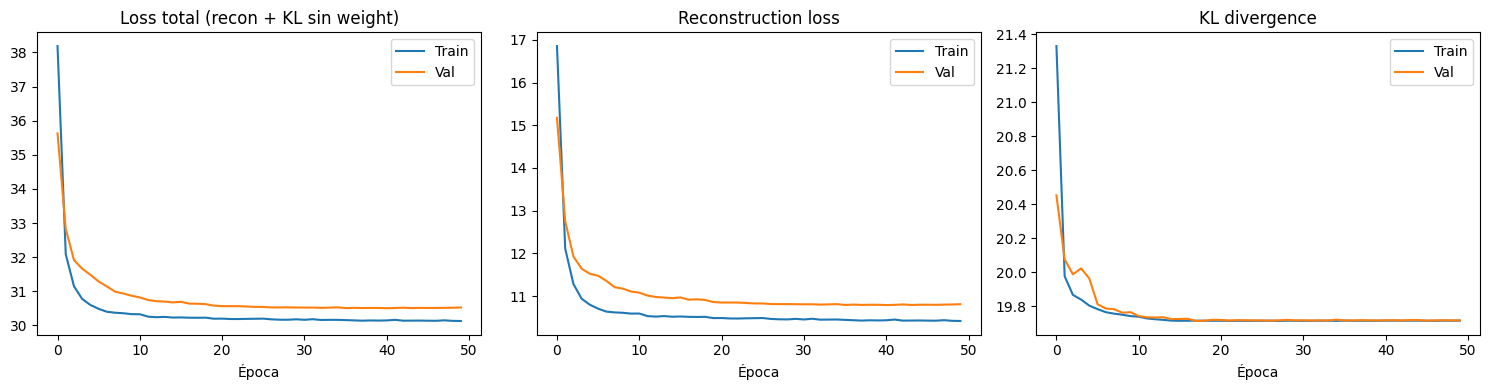


Error de predicción del siguiente timestep:
Split      |        MSE |        MAE
------------------------------------
Train      |     0.1548 |     0.1914
Val        |     0.1585 |     0.1920
Test       |     0.1554 |     0.1920

Predicción del siguiente estado para usuario de test:
Shape del vector predicho: (76,)

Features clave del siguiente estado predicho:
  monto                              : 0.3436
  tipo_operacion_compra              : 0.2373
  es_internacional                   : 0.0854
  categoria_mcc_freq                 : 0.0370
  patron_uso_atipico                 : -0.0657
Estabilidad de predicciones (50 muestras estocásticas):
  Desviación estándar promedio entre features: 0.0079
  Feature más inestable: saldo_actual (std=0.0212)
  Feature más estable:   dia_semana_cos (std=0.0037)

Top 10 features con más incertidumbre en la predicción:
  saldo_actual                            : media=-0.0759  std=0.0212
  grupo_edad                              : media=2.1435  std=0

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ================================================================
# 1. CARGAR MEJOR MODELO
# ================================================================

model.load_state_dict(torch.load('vrnn_best.pth'))
model.eval()
print("Mejor modelo cargado.")

# ================================================================
# 2. CURVAS DE ENTRENAMIENTO
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_loss_real = [r + k for r, k in zip(history['train_recon'], history['train_kl'])]
val_loss_real   = [r + k for r, k in zip(history['val_recon'],   history['val_kl'])]

axes[0].plot(train_loss_real, label='Train')
axes[0].plot(val_loss_real,   label='Val')
axes[0].set_title('Loss total (recon + KL sin weight)')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history['train_recon'], label='Train')
axes[1].plot(history['val_recon'],   label='Val')
axes[1].set_title('Reconstruction loss')
axes[1].set_xlabel('Época')
axes[1].legend()

axes[2].plot(history['train_kl'], label='Train')
axes[2].plot(history['val_kl'],   label='Val')
axes[2].set_title('KL divergence')
axes[2].set_xlabel('Época')
axes[2].legend()

plt.tight_layout()
plt.savefig('vrnn_training_curves.png', dpi=150)
plt.show()

# ================================================================
# 3. ERROR DE PREDICCIÓN EN TEST
# ================================================================

def evaluate_prediction_error(model, loader, device):
    """
    Para cada usuario en el loader, predice x_{t+1} y mide
    el error contra el x_{t+1} real en cada timestep.
    """
    model.eval()
    all_mse  = []
    all_mae  = []

    with torch.no_grad():
        for seq, mask, length in loader:
            seq  = seq.to(device)   # (batch, 50, 76)
            mask = mask.to(device)

            batch_size = seq.size(0)
            h = torch.zeros(model.n_layers, batch_size, model.hidden_dim).to(device)

            batch_mse = []
            batch_mae = []

            for t in range(seq.size(1) - 1):
                x_t    = seq[:, t, :]
                x_next = seq[:, t + 1, :]  # target real

                phi_x_t   = model.phi_x(x_t)
                h_last    = h[-1]

                enc_input = torch.cat([phi_x_t, h_last], dim=1)
                enc_t     = model.encoder(enc_input)
                enc_mu_t  = model.encoder_mu(enc_t)
                enc_lv_t  = model.encoder_logvar(enc_t)
                z_t       = model.reparameterize(enc_mu_t, enc_lv_t)
                phi_z_t   = model.phi_z(z_t)

                dec_input  = torch.cat([phi_z_t, h_last], dim=1)
                x_hat_next = model.decoder_out(model.decoder(dec_input))

                rnn_input = torch.cat([phi_x_t, phi_z_t], dim=1).unsqueeze(1)
                _, h      = model.rnn(rnn_input, h)

                # Solo evaluar en pasos reales (no padding)
                m = mask[:, t + 1]  # (batch,)

                mse = ((x_hat_next - x_next) ** 2).mean(dim=1)  # (batch,)
                mae = (x_hat_next - x_next).abs().mean(dim=1)    # (batch,)

                # Solo guardar pasos reales
                batch_mse.append((mse * m).sum().item() / (m.sum().item() + 1e-8))
                batch_mae.append((mae * m).sum().item() / (m.sum().item() + 1e-8))

            all_mse.append(np.mean(batch_mse))
            all_mae.append(np.mean(batch_mae))

    return np.mean(all_mse), np.mean(all_mae)

train_mse, train_mae = evaluate_prediction_error(model, train_loader, DEVICE)
val_mse,   val_mae   = evaluate_prediction_error(model, val_loader,   DEVICE)
test_mse,  test_mae  = evaluate_prediction_error(model, test_loader,  DEVICE)

print(f"\nError de predicción del siguiente timestep:")
print(f"{'Split':<10} | {'MSE':>10} | {'MAE':>10}")
print("-" * 36)
print(f"{'Train':<10} | {train_mse:>10.4f} | {train_mae:>10.4f}")
print(f"{'Val':<10} | {val_mse:>10.4f} | {val_mae:>10.4f}")
print(f"{'Test':<10} | {test_mse:>10.4f} | {test_mae:>10.4f}")

# ================================================================
# 4. PRUEBA REAL — predict_next en un usuario de test
# ================================================================

# Tomar un usuario del test set
sample_seq, sample_mask, sample_length = test_dataset[0]
sample_seq = sample_seq.unsqueeze(0).to(DEVICE)  # (1, 50, 76)

# Predecir su siguiente acción
x_next_pred = model.predict_next(sample_seq)  # (1, 76)
x_next_pred = x_next_pred.cpu().numpy()[0]     # (76,)

print(f"\nPredicción del siguiente estado para usuario de test:")
print(f"Shape del vector predicho: {x_next_pred.shape}")

# Mostrar las features más relevantes de la predicción
features_interes = {
    'monto':              feature_cols.index('monto'),
    'tipo_operacion_compra': feature_cols.index('tipo_operacion_compra') 
                             if 'tipo_operacion_compra' in feature_cols else None,
    'es_internacional':   feature_cols.index('es_internacional'),
    'categoria_mcc_freq': feature_cols.index('categoria_mcc_freq'),
    'patron_uso_atipico': feature_cols.index('patron_uso_atipico'),
}

print(f"\nFeatures clave del siguiente estado predicho:")
for nombre, idx in features_interes.items():
    if idx is not None:
        print(f"  {nombre:<35}: {x_next_pred[idx]:.4f}")

# ================================================================
# 5. ESTABILIDAD — predecir múltiples veces y medir varianza
# ================================================================

# Versión corregida: forzar modo training dentro de predict_next
n_samples    = 50
predicciones = []

with torch.no_grad():
    for _ in range(n_samples):
        batch_size = sample_seq.size(0)
        h = torch.zeros(model.n_layers, batch_size, model.hidden_dim).to(DEVICE)

        # Procesar historial en modo training (muestrea z)
        model.train()
        for t in range(sample_seq.size(1)):
            x_t     = sample_seq[:, t, :]
            phi_x_t = model.phi_x(x_t)
            h_last  = h[-1]

            enc_input = torch.cat([phi_x_t, h_last], dim=1)
            enc_t     = model.encoder(enc_input)
            enc_mu_t  = model.encoder_mu(enc_t)
            enc_lv_t  = model.encoder_logvar(enc_t)
            z_t       = model.reparameterize(enc_mu_t, enc_lv_t)
            phi_z_t   = model.phi_z(z_t)

            rnn_input = torch.cat([phi_x_t, phi_z_t], dim=1).unsqueeze(1)
            _, h      = model.rnn(rnn_input, h)

        # Predecir siguiente paso muestreando del prior
        h_last     = h[-1]
        prior_t    = model.prior(h_last)
        prior_mu_t = model.prior_mu(prior_t)
        prior_lv_t = model.prior_logvar(prior_t)
        z_next     = model.reparameterize(prior_mu_t, prior_lv_t)
        phi_z_next = model.phi_z(z_next)

        dec_input = torch.cat([phi_z_next, h_last], dim=1)
        x_next    = model.decoder_out(model.decoder(dec_input))

        predicciones.append(x_next.cpu().numpy()[0])

model.eval()

predicciones = np.array(predicciones)  # (50, 76)
media        = predicciones.mean(axis=0)
std_dev      = predicciones.std(axis=0)

print(f"Estabilidad de predicciones ({n_samples} muestras estocásticas):")
print(f"  Desviación estándar promedio entre features: {std_dev.mean():.4f}")
print(f"  Feature más inestable: {feature_cols[std_dev.argmax()]} "
      f"(std={std_dev.max():.4f})")
print(f"  Feature más estable:   {feature_cols[std_dev.argmin()]} "
      f"(std={std_dev.min():.4f})")

# Top 10 features con más incertidumbre
top_inestables = std_dev.argsort()[::-1][:10]
print(f"\nTop 10 features con más incertidumbre en la predicción:")
for idx in top_inestables:
    print(f"  {feature_cols[idx]:<40}: media={media[idx]:.4f}  std={std_dev[idx]:.4f}")

In [57]:
# ============================================================
# EXPORTACIÓN VRNN — CON DESNORMALIZACIÓN
# ============================================================
import joblib
import torch
import os

# ─── Verificar que el scaler tiene feature names ──────────
# Necesario para desnormalizar por columna en el chatbot
if not hasattr(scaler, 'feature_names_in_'):
    from sklearn.preprocessing import StandardScaler
    scaler_con_nombres = StandardScaler()
    scaler_con_nombres.fit(df_vrnn[numeric_cols])
    scaler_con_nombres.feature_names_in_ = np.array(numeric_cols)
else:
    scaler_con_nombres = scaler

print('✅ Scaler con nombres de features listo')

# ─── Guardar modelo ───────────────────────────────────────
if os.path.exists('vrnn_best.pth'):
    print('✅ vrnn_best.pth ya existe')
else:
    torch.save(model.state_dict(), 'vrnn_best.pth')

# ─── Guardar configuración ────────────────────────────────
vrnn_config = {
    'input_dim' : INPUT_DIM,
    'hidden_dim': HIDDEN_DIM,
    'latent_dim': LATENT_DIM,
    'n_layers'  : 1,
    'max_len'   : MAX_LEN
}
joblib.dump(vrnn_config, 'vrnn_config.pkl')

# ─── Guardar feature cols y scaler ────────────────────────
joblib.dump(feature_cols,       'vrnn_feature_cols.pkl')
joblib.dump(scaler_con_nombres, 'vrnn_scaler.pkl')
joblib.dump(numeric_cols,       'vrnn_numeric_cols.pkl')

# ─── Guardar índices de columnas numéricas ────────────────
# Para saber exactamente qué posiciones desnormalizar
idx_numericas = [
    i for i, col in enumerate(feature_cols)
    if col in numeric_cols
]
joblib.dump(idx_numericas, 'vrnn_idx_numericas.pkl')

# ─── Guardar mapa usuario → secuencia ─────────────────────
mapa_secuencias = {
    uid: sequences[i].numpy()
    for i, uid in enumerate(user_ids)
}
joblib.dump(mapa_secuencias, 'vrnn_mapa_secuencias.pkl')

# ─── Guardar freq map ─────────────────────────────────────
joblib.dump(freq_map, 'vrnn_freq_map_mcc.pkl')

# ─── Guardar historial ────────────────────────────────────
joblib.dump(history, 'vrnn_history.pkl')

# ─── Verificar ────────────────────────────────────────────
archivos = [
    'vrnn_best.pth',
    'vrnn_config.pkl',
    'vrnn_feature_cols.pkl',
    'vrnn_scaler.pkl',
    'vrnn_numeric_cols.pkl',
    'vrnn_idx_numericas.pkl',
    'vrnn_mapa_secuencias.pkl',
    'vrnn_freq_map_mcc.pkl',
    'vrnn_history.pkl'
]

print('\n─── Archivos exportados VRNN ───')
for archivo in archivos:
    existe = os.path.exists(archivo)
    size   = os.path.getsize(archivo) / 1024 if existe else 0
    print(f'  {"✅" if existe else "❌"} {archivo} ({size:.1f} KB)')

print(f'\nResumen VRNN:')
print(f'  Input dim:              {INPUT_DIM}')
print(f'  Hidden dim:             {HIDDEN_DIM}')
print(f'  Latent dim:             {LATENT_DIM}')
print(f'  Max len:                {MAX_LEN}')
print(f'  Features:               {len(feature_cols)}')
print(f'  Columnas numéricas:     {len(numeric_cols)}')
print(f'  Índices numéricas:      {len(idx_numericas)}')
print(f'  Usuarios con secuencia: {len(mapa_secuencias):,}')

✅ Scaler con nombres de features listo
✅ vrnn_best.pth ya existe

─── Archivos exportados VRNN ───
  ✅ vrnn_best.pth (4848.8 KB)
  ✅ vrnn_config.pkl (0.1 KB)
  ✅ vrnn_feature_cols.pkl (1.6 KB)
  ✅ vrnn_scaler.pkl (1.4 KB)
  ✅ vrnn_numeric_cols.pkl (0.3 KB)
  ✅ vrnn_idx_numericas.pkl (0.0 KB)
  ✅ vrnn_mapa_secuencias.pkl (223966.6 KB)
  ✅ vrnn_freq_map_mcc.pkl (1.8 KB)
  ✅ vrnn_history.pkl (2.7 KB)

Resumen VRNN:
  Input dim:              76
  Hidden dim:             256
  Latent dim:             64
  Max len:                50
  Features:               76
  Columnas numéricas:     14
  Índices numéricas:      14
  Usuarios con secuencia: 15,025


In [58]:
df_vrnn.to_csv('datos_finales.csv',index=False,encoding='utf-8-sig')